# MAFS5370 Project 1

## Project Overview
This project implements and compares seven different Reinforcement Learning (RL) algorithms for solving a dynamic portfolio optimization problem. The goal is to maximize the expected utility of final wealth over a fixed time horizon.

### Algorithms Implemented
- **Baselines**: Greedy Algorithm
- **Value-Based**: Q-Learning (with Adam adaptive learning rate)
- **Policy-Based**: REINFORCE, TRPO (Trust Region Policy Optimization)
- **Actor-Critic**: Basic Actor-Critic, A3C (Asynchronous Advantage Actor-Critic), PPO (Proximal Policy Optimization)

### Environment Configuration
- **Time Horizon (T)**: 8 steps
- **Assets**: 3 risky assets + 1 risk-free asset
- **Parameters**:
  - Expected Returns: `[-0.5, 0.5, 0.0]`
  - Variances: `[0.25, 0.25, 0.5]`
  - Risk-free Rate: `0.02`
  - Initial Wealth: `1.0` (Equally weighted at start: `[0.25, 0.25, 0.25, 0.25]`)
- **Constraints**:
  - No short selling allowed.
  - Action space discretized: weight changes $\in [-0.1, 0.1]$ with step size 0.01.
  - Total absolute weight adjustment per step $\leq 0.1$.
- **Utility Function**: CRRA Utility $U(W) = -\exp(-\gamma W)$ where $\gamma=1.0$.

### Training and Evaluation
- **Training**: 3000 episodes for each algorithm.
- **Evaluation**: 500 independent test episodes to measure performance (Mean Wealth and Mean Utility).

In [1]:
import numpy as np
import random
from collections import defaultdict
import pickle
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

np.random.seed(42)
random.seed(42)
torch.manual_seed(42)


class PortfolioEnv:
    def __init__(self, T, n_assets, a_list, s_list, r, p_list, risk_aversion=1.0, allow_short=False):
        self.T = T
        self.n_assets = n_assets
        self.a = np.array(a_list)
        self.s = np.array(s_list)
        self.r = r
        self.initial_p = np.array(p_list)
        self.risk_aversion = risk_aversion
        self.allow_short = allow_short
        self.reset()
    
    def reset(self):
        self.time = 0
        self.weights = self.initial_p.copy()
        self.current_wealth = 1.0
        return self._get_state()
    
    def _get_state(self):
        time_norm = self.time / self.T
        wealth_discrete = round(self.current_wealth, 2)
        weights_discrete = tuple(np.round(self.weights, 3))
        return (time_norm, wealth_discrete) + weights_discrete
    
    def _utility(self, wealth):
        """CRRA utility function: U(W) = -exp(-gamma * W)"""
        return -np.exp(-self.risk_aversion * wealth)
    
    def _check_feasible(self, deltas):
        if np.sum(np.abs(deltas)) > 0.1:
            return False, f"Total position change {np.sum(np.abs(deltas)):.3f} exceeds 10%"
        new_weights = self.weights.copy()
        new_weights[1:] += deltas
        new_weights[0] = 1.0 - np.sum(new_weights[1:])
        if not self.allow_short and np.any(new_weights < -1e-10):
            return False, "Short selling not allowed"
        return True, new_weights
    
    def step(self, deltas):
        feasible, result = self._check_feasible(deltas)
        if not feasible:
            self.time += 1
            if self.time >= self.T:
                done = True
                reward = self._utility(self.current_wealth)
            else:
                done = False
                reward = -0.01
            return self._get_state(), reward, done
        
        self.weights = result
        stock_returns = np.random.normal(self.a, np.sqrt(self.s))
        cash_return = self.r
        portfolio_return = np.sum(self.weights[1:] * stock_returns) + self.weights[0] * cash_return
        self.current_wealth *= (1 + portfolio_return)
        self.time += 1
        
        if self.time >= self.T:
            reward = self._utility(self.current_wealth)
            done = True
        else:
            reward = 0
            done = False
        
        return self._get_state(), reward, done

def generate_actions(n_assets):
    actions = []
    values = [-0.10, -0.09, -0.08, -0.07, -0.06, -0.05, -0.04, -0.03, -0.02, -0.01, 
              0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10]
    
    def generate(current_action, idx, remaining_sum):
        if idx == n_assets:
            if sum(abs(x) for x in current_action) <= 0.1 + 1e-10:
                actions.append(current_action.copy())
            return
        for v in values:
            if abs(v) <= remaining_sum:
                current_action[idx] = v
                generate(current_action, idx + 1, remaining_sum - abs(v))
    
    generate([0.0] * n_assets, 0, 0.1)
    return np.array(actions)


class AdaptiveQLearningAgent:
    def __init__(self, n_assets, initial_alpha=0.1, gamma=0.95, epsilon=0.2, 
                 alpha_strategy='adam', min_alpha=0.001, max_alpha=0.5):
        self.n_assets = n_assets
        self.initial_alpha = initial_alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.alpha_strategy = alpha_strategy
        self.min_alpha = min_alpha
        self.max_alpha = max_alpha
        self.episode_count = 0
        
        print("Generating action space...")
        self.actions = self._generate_actions()
        self.n_actions = len(self.actions)
        print(f"Total actions generated: {self.n_actions}")
        
        self.q_table = defaultdict(float)
        
        if alpha_strategy == 'adam':
            self.m = defaultdict(float)
            self.v = defaultdict(float)
            self.beta1 = 0.9
            self.beta2 = 0.999
            self.eps = 1e-8
            self.t = 0
            
        elif alpha_strategy == 'td_error':
            self.alpha_table = defaultdict(lambda: initial_alpha)
            self.error_history = defaultdict(list)
            self.error_window = 10
            self.adaptation_rate = 0.01
            
        elif alpha_strategy == 'step_decay':
            self.current_alpha = initial_alpha
            self.decay_factor = 0.995
            self.decay_every = 100
            
        elif alpha_strategy == 'fixed':
            self.current_alpha = initial_alpha
    
    def _generate_actions(self):
        actions = []
        values = [-0.10, -0.09, -0.08, -0.07, -0.06, -0.05, -0.04, -0.03, -0.02, -0.01, 
                  0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10]
        
        def generate(current_action, idx, remaining_sum):
            if idx == self.n_assets:
                if sum(abs(x) for x in current_action) <= 0.1 + 1e-10:
                    actions.append(current_action.copy())
                return
            for v in values:
                if abs(v) <= remaining_sum:
                    current_action[idx] = v
                    generate(current_action, idx + 1, remaining_sum - abs(v))
        
        generate([0.0] * self.n_assets, 0, 0.1)
        return actions
    
    def get_alpha(self, state, action=None):
        if self.alpha_strategy in ['fixed', 'step_decay']:
            return self.current_alpha
        elif self.alpha_strategy == 'td_error':
            return self.alpha_table[(state, action)] if action is not None else self.initial_alpha
        elif self.alpha_strategy == 'adam':
            return self.initial_alpha
        return self.initial_alpha
    
    def _update_alpha_td_error(self, state, action, td_error):
        key = (state, action)
        self.error_history[key].append(abs(td_error))
        if len(self.error_history[key]) > self.error_window:
            self.error_history[key].pop(0)
        
        if len(self.error_history[key]) >= 2:
            recent_mean = np.mean(self.error_history[key][-5:])
            older_mean = np.mean(self.error_history[key][:5]) if len(self.error_history[key]) >= 5 else recent_mean
            
            if recent_mean > older_mean * 1.1:
                new_alpha = self.alpha_table[key] * (1 - self.adaptation_rate)
            elif recent_mean < older_mean * 0.9:
                new_alpha = self.alpha_table[key] * (1 + self.adaptation_rate * 0.5)
            else:
                new_alpha = self.alpha_table[key]
            
            self.alpha_table[key] = np.clip(new_alpha, self.min_alpha, self.max_alpha)
    
    def _update_alpha_adam(self, state, action, td_error):
        key = (state, action)
        self.t += 1
        g = td_error
        self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * g
        self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * (g ** 2)
        m_hat = self.m[key] / (1 - self.beta1 ** self.t)
        v_hat = self.v[key] / (1 - self.beta2 ** self.t)
        adaptive_step = self.initial_alpha * m_hat / (np.sqrt(v_hat) + self.eps)
        return adaptive_step
    
    def get_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)
        else:
            q_values = [self.q_table[(state, a)] for a in range(self.n_actions)]
            return np.argmax(q_values)
    
    def learn(self, state, action, reward, next_state, done):
        current_q = self.q_table[(state, action)]
        
        if done:
            target_q = reward
        else:
            next_q_values = [self.q_table[(next_state, a)] for a in range(self.n_actions)]
            target_q = reward + self.gamma * max(next_q_values)
        
        td_error = target_q - current_q
        
        if self.alpha_strategy == 'adam':
            adaptive_step = self._update_alpha_adam(state, action, td_error)
            self.q_table[(state, action)] = current_q + adaptive_step
            
        elif self.alpha_strategy == 'td_error':
            alpha = self.get_alpha(state, action)
            self.q_table[(state, action)] = current_q + alpha * td_error
            self._update_alpha_td_error(state, action, td_error)
            
        elif self.alpha_strategy in ['fixed', 'step_decay']:
            alpha = self.get_alpha(state, action)
            self.q_table[(state, action)] = current_q + alpha * td_error
        
        return abs(td_error)
    
    def on_episode_end(self):
        self.episode_count += 1
        if self.alpha_strategy == 'step_decay':
            if self.episode_count % self.decay_every == 0:
                old_alpha = self.current_alpha
                self.current_alpha = max(self.min_alpha, self.current_alpha * self.decay_factor)
                if self.episode_count % 1000 == 0:
                    print(f"  Episode {self.episode_count}: alpha decayed {old_alpha:.4f} -> {self.current_alpha:.4f}")
    
    def get_learning_stats(self):
        if self.alpha_strategy == 'td_error':
            alphas = list(self.alpha_table.values())
            if alphas:
                return {
                    'alpha_mean': np.mean(alphas),
                    'alpha_std': np.std(alphas),
                    'alpha_min': np.min(alphas),
                    'alpha_max': np.max(alphas),
                    'n_states': len(alphas)
                }
        elif self.alpha_strategy == 'step_decay':
            return {'current_alpha': self.current_alpha}
        return {}
    
    def train_episode(self, env):
        state = env.reset()
        done = False
        
        while not done:
            action = self.get_action(state)
            deltas = self.actions[action]
            next_state, reward, done = env.step(deltas)
            self.learn(state, action, reward, next_state, done)
            state = next_state
        
        self.on_episode_end()
        return env.current_wealth, env._utility(env.current_wealth)


class GreedyAgent:
    def __init__(self, n_assets, actions):
        self.n_assets = n_assets
        self.actions = actions
        self.n_actions = len(actions)
        self.name = "Greedy"
    
    def get_action(self, state, env):
        """greedy: choosing the action with highest return"""
        best_action = 0
        best_expected_return = -np.inf
        
        for i, action in enumerate(self.actions):
            test_weights = env.weights.copy()
            test_weights[1:] += action
            test_weights[0] = 1.0 - np.sum(test_weights[1:])
            
            if np.any(test_weights < -1e-10) and not env.allow_short:
                continue
            
            expected_return = np.sum(test_weights[1:] * env.a) + test_weights[0] * env.r
            if expected_return > best_expected_return:
                best_expected_return = expected_return
                best_action = i
        
        return best_action
    
    def train_episode(self, env):
        state = env.reset()
        done = False
        
        while not done:
            action = self.get_action(state, env)
            deltas = self.actions[action]
            next_state, reward, done = env.step(deltas)
            state = next_state
        
        return env.current_wealth, env._utility(env.current_wealth)

class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Softmax(dim=-1)
        )
    
    def forward(self, x):
        return self.fc(x)

class REINFORCEAgent:
    def __init__(self, n_assets, actions, lr=0.001, gamma=0.99):
        self.n_assets = n_assets
        self.actions = actions
        self.n_actions = len(actions)
        self.gamma = gamma
    
        state_dim = 2 + n_assets + 1
        self.policy = PolicyNetwork(state_dim, self.n_actions)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)
        
        self.saved_log_probs = []
        self.rewards = []
    
    def _state_to_tensor(self, state):
        return torch.FloatTensor(list(state))
    
    def select_action(self, state):
        state_tensor = self._state_to_tensor(state).unsqueeze(0)
        probs = self.policy(state_tensor)
        dist = Categorical(probs)
        action = dist.sample()
        self.saved_log_probs.append(dist.log_prob(action))
        return action.item()
    
    def store_reward(self, reward):
        self.rewards.append(reward)
    
    def update(self):
        if len(self.rewards) == 0:
            return 0
            
        returns = []
        R = 0
        for r in reversed(self.rewards):
            R = r + self.gamma * R
            returns.insert(0, R)
        
        returns = torch.FloatTensor(returns)
        
        if returns.std() > 1e-9:
            returns = (returns - returns.mean()) / (returns.std() + 1e-9)
        else:
            returns = returns - returns.mean()
        
        policy_loss = []
        for log_prob, R in zip(self.saved_log_probs, returns):
            policy_loss.append(-log_prob * R)
        
        self.optimizer.zero_grad()
        loss = torch.stack(policy_loss).sum()
        loss.backward()
        self.optimizer.step()
        
        self.saved_log_probs = []
        self.rewards = []
        
        return loss.item()
    
    def train_episode(self, env):
        state = env.reset()
        done = False
        
        while not done:
            action_idx = self.select_action(state)
            deltas = self.actions[action_idx]
            next_state, reward, done = env.step(deltas)
            self.store_reward(reward)
            state = next_state
        
        loss = self.update()
        return env.current_wealth, env._utility(env.current_wealth)


# ==================== 4. Actor-Critic ====================

class ValueNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim=128):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, x):
        return self.fc(x).squeeze(-1)

class ActorCriticAgent:
    def __init__(self, n_assets, actions, lr=0.001, gamma=0.99, value_coef=0.5, entropy_coef=0.01):
        self.n_assets = n_assets
        self.actions = actions
        self.n_actions = len(actions)
        self.gamma = gamma
        self.value_coef = value_coef
        self.entropy_coef = entropy_coef
        
        state_dim = 2 + n_assets + 1
        self.actor = PolicyNetwork(state_dim, self.n_actions)
        self.critic = ValueNetwork(state_dim)
        self.optimizer = optim.Adam(
            list(self.actor.parameters()) + list(self.critic.parameters()), 
            lr=lr
        )
    
    def _state_to_tensor(self, state):
        return torch.FloatTensor(list(state))
    
    def select_action(self, state):
        state_tensor = self._state_to_tensor(state).unsqueeze(0)
        probs = self.actor(state_tensor)
        value = self.critic(state_tensor)
        dist = Categorical(probs)
        action = dist.sample()
        return action.item(), dist.log_prob(action), dist.entropy(), value
    
    def train_episode(self, env):
        state = env.reset()
        done = False
        log_probs = []
        values = []
        rewards = []
        entropies = []
        
        while not done:
            action_idx, log_prob, entropy, value = self.select_action(state)
            deltas = self.actions[action_idx]
            next_state, reward, done = env.step(deltas)
            
            log_probs.append(log_prob)
            values.append(value)
            rewards.append(reward)
            entropies.append(entropy)
            state = next_state
    
        returns = []
        R = 0
        for r in reversed(rewards):
            R = r + self.gamma * R
            returns.insert(0, R)
        returns = torch.FloatTensor(returns)
        
        if len(values) > 0:
            values = torch.cat(values)
        else:
            return env.current_wealth, env._utility(env.current_wealth)
        
        # 确保维度匹配
        advantages = returns - values.detach()
        
        log_probs = torch.cat(log_probs)
        entropies = torch.cat(entropies)
        
        actor_loss = -(log_probs * advantages).mean()
        critic_loss = nn.MSELoss()(values, returns)
        entropy_loss = -entropies.mean()
        
        loss = actor_loss + self.value_coef * critic_loss + self.entropy_coef * entropy_loss
        
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
        torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)
        self.optimizer.step()
    
        return env.current_wealth, env._utility(env.current_wealth)


# ==================== 5. PPO ====================

class PPOAgent:
    def __init__(self, n_assets, actions, lr=0.0003, gamma=0.99, 
                 epsilon=0.2, value_coef=0.5, entropy_coef=0.01, 
                 update_epochs=4, batch_size=64):
        self.n_assets = n_assets
        self.actions = actions
        self.n_actions = len(actions)
        self.gamma = gamma
        self.epsilon = epsilon
        self.value_coef = value_coef
        self.entropy_coef = entropy_coef
        self.update_epochs = update_epochs
        self.batch_size = batch_size
        self.gae_lambda = 0.95
        
        state_dim = 2 + n_assets + 1
        self.actor = PolicyNetwork(state_dim, self.n_actions)
        self.critic = ValueNetwork(state_dim)
        self.optimizer = optim.Adam(
            list(self.actor.parameters()) + list(self.critic.parameters()),
            lr=lr
        )
        
        self.states = []
        self.actions_buffer = []
        self.rewards = []
        self.log_probs = []
        self.values = []
        self.dones = []
    
    def _state_to_tensor(self, state):
        return torch.FloatTensor(list(state))
    
    def select_action(self, state):
        state_tensor = self._state_to_tensor(state).unsqueeze(0)
        with torch.no_grad():
            probs = self.actor(state_tensor)
            value = self.critic(state_tensor)
        dist = Categorical(probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action.item(), log_prob.item(), value.item()
    
    def store_transition(self, state, action, reward, log_prob, value, done):
        self.states.append(list(state))
        self.actions_buffer.append(action)
        self.rewards.append(reward)
        self.log_probs.append(log_prob)
        self.values.append(value)
        self.dones.append(done)
    
    def compute_gae(self, rewards, values, dones, next_value):
        advantages = []
        gae = 0
        
        for t in reversed(range(len(rewards))):
            if t == len(rewards) - 1:
                next_val = next_value
            else:
                next_val = values[t + 1]
            
            if dones[t]:
                delta = rewards[t] - values[t]
                gae = delta
            else:
                delta = rewards[t] + self.gamma * next_val - values[t]
                gae = delta + self.gamma * self.gae_lambda * gae
            
            advantages.insert(0, gae)
        
        returns = [adv + val for adv, val in zip(advantages, values)]
        return advantages, returns
    
    def update(self):
        if len(self.states) == 0:
            return 0
        
        states = torch.FloatTensor(self.states)
        actions = torch.LongTensor(self.actions_buffer)
        old_log_probs = torch.FloatTensor(self.log_probs)
        
        with torch.no_grad():
            next_state_tensor = torch.FloatTensor(self.states[-1]).unsqueeze(0)
            next_value = self.critic(next_state_tensor).item()
        
        advantages, returns = self.compute_gae(self.rewards, self.values, self.dones, next_value)
        advantages = torch.FloatTensor(advantages)
        returns = torch.FloatTensor(returns)
        
        if advantages.std() > 1e-9:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        
        total_loss = 0
        dataset_size = len(states)
        
        for _ in range(self.update_epochs):
            indices = torch.randperm(dataset_size)
            for start in range(0, dataset_size, self.batch_size):
                end = min(start + self.batch_size, dataset_size)
                idx = indices[start:end]
                
                batch_states = states[idx]
                batch_actions = actions[idx]
                batch_old_log_probs = old_log_probs[idx]
                batch_advantages = advantages[idx]
                batch_returns = returns[idx]
                
                probs = self.actor(batch_states)
                values = self.critic(batch_states)
                dist = Categorical(probs)
                new_log_probs = dist.log_prob(batch_actions)
                entropy = dist.entropy().mean()
                
                ratio = torch.exp(new_log_probs - batch_old_log_probs)
                
                surr1 = ratio * batch_advantages
                surr2 = torch.clamp(ratio, 1 - self.epsilon, 1 + self.epsilon) * batch_advantages
                actor_loss = -torch.min(surr1, surr2).mean()
                
                critic_loss = nn.MSELoss()(values, batch_returns)
                
                loss = actor_loss + self.value_coef * critic_loss - self.entropy_coef * entropy
                
                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
                torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)
                self.optimizer.step()
                
                total_loss += loss.item()
        
        self.states = []
        self.actions_buffer = []
        self.rewards = []
        self.log_probs = []
        self.values = []
        self.dones = []
        
        return total_loss
    
    def train_episode(self, env):
        state = env.reset()
        done = False
        
        while not done:
            action_idx, log_prob, value = self.select_action(state)
            deltas = self.actions[action_idx]
            next_state, reward, done = env.step(deltas)
            self.store_transition(state, action_idx, reward, log_prob, value, done)
            state = next_state
        
        loss = self.update()
        # 返回原始负效用值
        return env.current_wealth, env._utility(env.current_wealth)


# ==================== 6. A3C ====================

class A3CAgent:
    def __init__(self, n_assets, actions, lr=0.001, gamma=0.99, n_workers=4):
        self.n_assets = n_assets
        self.actions = actions
        self.n_actions = len(actions)
        self.gamma = gamma
        self.n_workers = n_workers
        
        state_dim = 2 + n_assets + 1
        self.global_actor = PolicyNetwork(state_dim, self.n_actions)
        self.global_critic = ValueNetwork(state_dim)
        self.optimizer = optim.Adam(
            list(self.global_actor.parameters()) + list(self.global_critic.parameters()),
            lr=lr
        )
    
    def _state_to_tensor(self, state):
        return torch.FloatTensor(list(state))
    
    def select_action(self, state):
        with torch.no_grad():
            state_tensor = self._state_to_tensor(state).unsqueeze(0)
            probs = self.global_actor(state_tensor)
            dist = Categorical(probs)
            action = dist.sample()
            return action.item()
    
    def collect_trajectory(self, env):
        state = env.reset()
        done = False
        trajectory = []
        
        while not done:
            action_idx = self.select_action(state)
            deltas = self.actions[action_idx]
            next_state, reward, done = env.step(deltas)
            trajectory.append((list(state), action_idx, reward, list(next_state), done))
            state = next_state
        
        return trajectory, env.current_wealth, env._utility(env.current_wealth)
    
    def update(self, trajectories):
        total_loss = 0
        
        for trajectory in trajectories:
            if len(trajectory) == 0:
                continue
                
            states = torch.FloatTensor([t[0] for t in trajectory])
            actions = torch.LongTensor([t[1] for t in trajectory])
            rewards = [t[2] for t in trajectory]
            
            returns = []
            R = 0
            for r in reversed(rewards):
                R = r + self.gamma * R
                returns.insert(0, R)
            returns = torch.FloatTensor(returns)
            
            probs = self.global_actor(states)
            values = self.global_critic(states)
            dist = Categorical(probs)
            log_probs = dist.log_prob(actions)
            
            advantages = returns - values.detach()
            
            actor_loss = -(log_probs * advantages).mean()
            critic_loss = nn.MSELoss()(values, returns)
            loss = actor_loss + 0.5 * critic_loss
            
            total_loss += loss.item()
            
            self.optimizer.zero_grad()
            loss.backward()
        
        torch.nn.utils.clip_grad_norm_(self.global_actor.parameters(), 0.5)
        torch.nn.utils.clip_grad_norm_(self.global_critic.parameters(), 0.5)
        self.optimizer.step()
        
        return total_loss / len(trajectories) if trajectories else 0
    
    def train_episode(self, env):
        trajectories = []
        wealths = []
        utilities = []
        
        for _ in range(self.n_workers):
            traj, w, u = self.collect_trajectory(env)
            trajectories.append(traj)
            wealths.append(w)
            utilities.append(u)
        
        loss = self.update(trajectories)
        return np.mean(wealths), np.mean(utilities)



# ==================== 7. TRPO====================

class TRPOAgent:
    def __init__(self, n_assets, actions, gamma=0.99, max_kl=0.01):
        self.n_assets = n_assets
        self.actions = actions
        self.n_actions = len(actions)
        self.gamma = gamma
        self.max_kl = max_kl
        self.gae_lambda = 0.95
        
        state_dim = 2 + n_assets + 1
        self.policy = PolicyNetwork(state_dim, self.n_actions)
        self.value_net = ValueNetwork(state_dim)
        self.policy_optimizer = optim.Adam(self.policy.parameters(), lr=0.001)
        self.value_optimizer = optim.Adam(self.value_net.parameters(), lr=0.002)
    
    def _state_to_tensor(self, state):
        return torch.FloatTensor(list(state))
    
    def select_action(self, state):
        with torch.no_grad():
            state_tensor = self._state_to_tensor(state).unsqueeze(0)
            probs = self.policy(state_tensor)
            dist = Categorical(probs)
            action = dist.sample()
            log_prob = dist.log_prob(action)
            return action.item(), log_prob.item()
    
    def collect_trajectory(self, env):
        state = env.reset()
        done = False
        trajectory = []
        
        while not done:
            action_idx, log_prob = self.select_action(state)
            deltas = self.actions[action_idx]
            next_state, reward, done = env.step(deltas)
            trajectory.append((list(state), action_idx, reward, log_prob, done))
            state = next_state
        
        return trajectory, env.current_wealth, env._utility(env.current_wealth)
    
    def compute_advantages(self, trajectory):
        rewards = [t[2] for t in trajectory]
        dones = [t[4] for t in trajectory]
        states = torch.FloatTensor([t[0] for t in trajectory])
        
        with torch.no_grad():
            values = self.value_net(states).numpy()
        
        advantages = []
        returns = []
        gae = 0
        
        for t in reversed(range(len(trajectory))):
            if t == len(trajectory) - 1:
                next_value = 0
            else:
                next_value = values[t + 1]
            
            if dones[t]:
                delta = rewards[t] - values[t]
                gae = delta
            else:
                delta = rewards[t] + self.gamma * next_value - values[t]
                gae = delta + self.gamma * self.gae_lambda * gae
            
            advantages.insert(0, gae)
            returns.insert(0, gae + values[t])
        
        return torch.FloatTensor(advantages), torch.FloatTensor(returns)
    
    def conjugate_gradient(self, f_Ax, b, nsteps=10, residual_tol=1e-10):
        x = torch.zeros_like(b)
        r = b.clone()
        p = b.clone()
        rdotr = torch.dot(r, r)
        
        for _ in range(nsteps):
            Ap = f_Ax(p)
            alpha = rdotr / (torch.dot(p, Ap) + 1e-8)
            x = x + alpha * p
            r = r - alpha * Ap
            new_rdotr = torch.dot(r, r)
            if new_rdotr < residual_tol:
                break
            beta = new_rdotr / rdotr
            p = r + beta * p
            rdotr = new_rdotr
        
        return x
    
    def compute_kl_loss(self, states, old_probs, old_log_probs):
        probs = self.policy(states)
        old_dist = Categorical(probs=old_probs)
        new_dist = Categorical(probs=probs)
        kl = torch.distributions.kl_divergence(old_dist, new_dist).mean()
        return kl
    
    def train_episode(self, env):
        trajectory, wealth, utility = self.collect_trajectory(env)
        
        if len(trajectory) == 0:
            return wealth, utility
        
        states = torch.FloatTensor([t[0] for t in trajectory])
        actions = torch.LongTensor([t[1] for t in trajectory])
        
        with torch.no_grad():
            old_probs = self.policy(states)
        
        advantages, returns = self.compute_advantages(trajectory)
        if advantages.std() > 1e-9:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        
        probs = self.policy(states)
        dist = Categorical(probs)
        log_probs = dist.log_prob(actions)
        
        ratio = torch.exp(log_probs - log_probs.detach())
        surr_loss = -(ratio * advantages).mean()
        
        self.policy_optimizer.zero_grad()
        surr_loss.backward()
        
        policy_grad = []
        for param in self.policy.parameters():
            if param.grad is not None:
                policy_grad.append(param.grad.view(-1))
        
        if len(policy_grad) == 0:
            for _ in range(5):
                values = self.value_net(states)
                value_loss = nn.MSELoss()(values, returns)
                self.value_optimizer.zero_grad()
                value_loss.backward()
                self.value_optimizer.step()
            return wealth, utility
        
        policy_grad = torch.cat(policy_grad)
        
        def f_Ax(x):
            kl = self.compute_kl_loss(states, old_probs, log_probs)
            grads = torch.autograd.grad(kl, self.policy.parameters(), create_graph=True, retain_graph=True)
            flat_grads = torch.cat([g.contiguous().view(-1) for g in grads if g is not None])
            if flat_grads.shape[0] != x.shape[0]:
                if flat_grads.shape[0] < x.shape[0]:
                    flat_grads = torch.cat([flat_grads, torch.zeros(x.shape[0] - flat_grads.shape[0], device=x.device)])
                else:
                    flat_grads = flat_grads[:x.shape[0]]
            kl_grad = (flat_grads * x).sum()
            grads2 = torch.autograd.grad(kl_grad, self.policy.parameters(), retain_graph=True)
            flat_grads2 = torch.cat([g.contiguous().view(-1) for g in grads2 if g is not None])
            if flat_grads2.shape[0] != x.shape[0]:
                if flat_grads2.shape[0] < x.shape[0]:
                    flat_grads2 = torch.cat([flat_grads2, torch.zeros(x.shape[0] - flat_grads2.shape[0], device=x.device)])
                else:
                    flat_grads2 = flat_grads2[:x.shape[0]]
            return flat_grads2 + 0.1 * x
        
        step_dir = self.conjugate_gradient(f_Ax, policy_grad)
        
        shs = 0.5 * torch.dot(step_dir, f_Ax(step_dir))
        lm = torch.sqrt(shs / self.max_kl)
        full_step = step_dir / (lm + 1e-8)
        
        old_params = torch.cat([p.data.view(-1) for p in self.policy.parameters()])
        new_params = old_params + full_step
        
        idx = 0
        for param in self.policy.parameters():
            param_length = param.numel()
            param.data.copy_(new_params[idx:idx+param_length].view(param.shape))
            idx += param_length
        
        for _ in range(5):
            values = self.value_net(states)
            value_loss = nn.MSELoss()(values, returns)
            self.value_optimizer.zero_grad()
            value_loss.backward()
            self.value_optimizer.step()
        
        return wealth, utility



def train_algorithm(name, agent, env, episodes=3000, log_interval=1000):
    wealth_history = []
    utility_history = []
    
    for episode in tqdm(range(episodes), desc=f"Training {name}"):
        wealth, utility = agent.train_episode(env)
        wealth_history.append(wealth)
        utility_history.append(utility)
        
        if (episode + 1) % log_interval == 0:
            recent_wealth = np.mean(wealth_history[-100:])
            recent_utility = np.mean(utility_history[-100:])
            print(f"  Episode {episode + 1}: Wealth={recent_wealth:.4f}, Utility={recent_utility:.4f}")
    
    return wealth_history, utility_history


def evaluate_algorithm(name, agent, env, actions, n_tests=500):
    """评估训练好的策略"""
    utilities = []
    wealths = []
    
    for _ in tqdm(range(n_tests), desc=f"Evaluating {name}"):
        state = env.reset()
        done = False
        
        while not done:
            if name == "Greedy":
                action_idx = agent.get_action(state, env)
            elif name == "Q-Learning":
                q_values = [agent.q_table[(state, a)] for a in range(agent.n_actions)]
                action_idx = np.argmax(q_values)
            elif hasattr(agent, 'select_action'):
                with torch.no_grad():
                    state_tensor = torch.FloatTensor(list(state)).unsqueeze(0)
                    if hasattr(agent, 'actor'):
                        probs = agent.actor(state_tensor)
                    elif hasattr(agent, 'policy'):
                        probs = agent.policy(state_tensor)
                    elif hasattr(agent, 'global_actor'):
                        probs = agent.global_actor(state_tensor)
                    else:
                        probs = agent.actor(state_tensor) if hasattr(agent, 'actor') else agent.policy(state_tensor)
                    action_idx = torch.argmax(probs).item()
            else:
                action_idx = 0
            
            deltas = actions[action_idx]
            next_state, reward, done = env.step(deltas)
            state = next_state
        
        utilities.append(env._utility(env.current_wealth))
        wealths.append(env.current_wealth)
    
    return {
        'mean_wealth': np.mean(wealths),
        'std_wealth': np.std(wealths),
        'mean_utility': np.mean(utilities),
        'std_utility': np.std(utilities),
        'utilities': utilities,
        'wealths': wealths
    }


# ==================== visualization ====================

def plot_comparison(results, window=100):
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    # Delete the 6th subplot as requested
    fig.delaxes(axes[1, 2])
    
    colors = {
        'Greedy': '#7f8c8d',       # Gray
        'Q-Learning': '#e74c3c',    # Red
        'REINFORCE': '#3498db',     # Blue
        'Actor-Critic': '#2ecc71',  # Green
        'A3C': '#9b59b6',           # Purple
        'PPO': '#f1c40f',           # Yellow
        'TRPO': '#e67e22'           # Orange
    }
    
    # utility curve
    ax = axes[0, 0]
    for name, data in results.items():
        utilities = data['utility_history']
        if len(utilities) > window:
            ma = np.convolve(utilities, np.ones(window)/window, mode='valid')
            ax.plot(range(window-1, len(utilities)), ma, 
                   label=name, color=colors[name], linewidth=2)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Utility')
    ax.set_title('Utility Learning Curve (Moving Avg)')
    ax.legend(fontsize='small', ncol=2)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # wealth curve
    ax = axes[0, 1]
    for name, data in results.items():
        wealths = data['wealth_history']
        if len(wealths) > window:
            ma = np.convolve(wealths, np.ones(window)/window, mode='valid')
            ax.plot(range(window-1, len(wealths)), ma, 
                   label=name, color=colors[name], linewidth=2)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Final Wealth')
    ax.set_title('Wealth Learning Curve (Moving Avg)')
    ax.legend(fontsize='small', ncol=2)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # utility distribution
    ax = axes[0, 2]
    eval_data = [results[name]['eval']['utilities'] for name in results.keys()]
    bp = ax.boxplot(eval_data, tick_labels=results.keys(), patch_artist=True, showfliers=False)
    for patch, name in zip(bp['boxes'], results.keys()):
        patch.set_facecolor(colors[name])
        patch.set_alpha(0.7)
    ax.set_ylabel('Utility')
    ax.set_title('Utility Distribution')
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # average utility
    ax = axes[1, 0]
    means = [results[name]['eval']['mean_utility'] for name in results.keys()]
    stds = [results[name]['eval']['std_utility'] for name in results.keys()]
    ax.bar(results.keys(), means, yerr=stds, 
                  color=[colors[name] for name in results.keys()],
                  capsize=5, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_ylabel('Average Utility')
    ax.set_title('Mean Utility Comparison')
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # average wealth
    ax = axes[1, 1]
    means = [results[name]['eval']['mean_wealth'] for name in results.keys()]
    stds = [results[name]['eval']['std_wealth'] for name in results.keys()]
    ax.bar(results.keys(), means, yerr=stds, 
                  color=[colors[name] for name in results.keys()],
                  capsize=5, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_ylabel('Average Wealth')
    ax.set_title('Mean Wealth Comparison')
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig('portfolio_rl_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n" + "="*80)
    print("SUMMARY PERFORMANCE METRICS")
    print("="*80)
    print(f"{'Algorithm':<15} {'Mean Utility':<15} {'Std Utility':<15} {'Mean Wealth':<15} {'Std Wealth':<15}")
    print("-"*80)
    for name in results.keys():
        eval_data = results[name]['eval']
        print(f"{name:<15} {eval_data['mean_utility']:<15.4f} "
              f"{eval_data['std_utility']:<15.4f} "
              f"{eval_data['mean_wealth']:<15.4f} "
              f"{eval_data['std_wealth']:<15.4f}")
    print("="*80)
    
    
    plt.tight_layout()
    plt.savefig('policy_gradient_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*100)
    print("FINAL COMPARISON RESULTS")
    print("="*100)
    print(f"{'Algorithm':<15} {'Mean Utility':<15} {'Std Utility':<15} {'Mean Wealth':<15} {'Std Wealth':<15}")
    print("-"*100)
    for name in results.keys():
        eval_data = results[name]['eval']
        print(f"{name:<15} {eval_data['mean_utility']:<15.4f} "
              f"{eval_data['std_utility']:<15.4f} "
              f"{eval_data['mean_wealth']:<15.4f} "
              f"{eval_data['std_wealth']:<15.4f}")
    print("="*100)



Environment Parameters:
  Time horizon T = 8
  Number of assets = 3
  Expected returns = [-0.5, 0.5, 0.0]
  Return variances = [0.25, 0.25, 0.5]
  Risk-free rate = 0.02
  Initial weights = [0.25, 0.25, 0.25, 0.25]
  Risk aversion = 1.0
  Allow short selling = False
Total actions: 1537

Testing Greedy Algorithm (Baseline)...


Testing Greedy:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating Greedy: 100%|██████████| 500/500 [02:58<00:00,  2.80it/s]


Greedy - Test Wealth: 5.2517 ± 4.4217, Test Utility: -0.0815 ± 0.1450

Training Q-Learning (Adam adaptive α)...
Generating action space...
Total actions generated: 1537


Training Q-Learning:  34%|███▎      | 1011/3000 [00:18<00:30, 65.15it/s]

...

  Episode 2000: Wealth=0.3968, Utility=-0.7099


Training TRPO: 100%|██████████| 3000/3000 [04:59<00:00, 10.02it/s]


  Episode 3000: Wealth=0.2986, Utility=-0.7814


Evaluating TRPO: 100%|██████████| 500/500 [00:01<00:00, 455.30it/s]


TRPO - Test Wealth: 0.5089 ± 0.4245, Test Utility: -0.6464 ± 0.2123



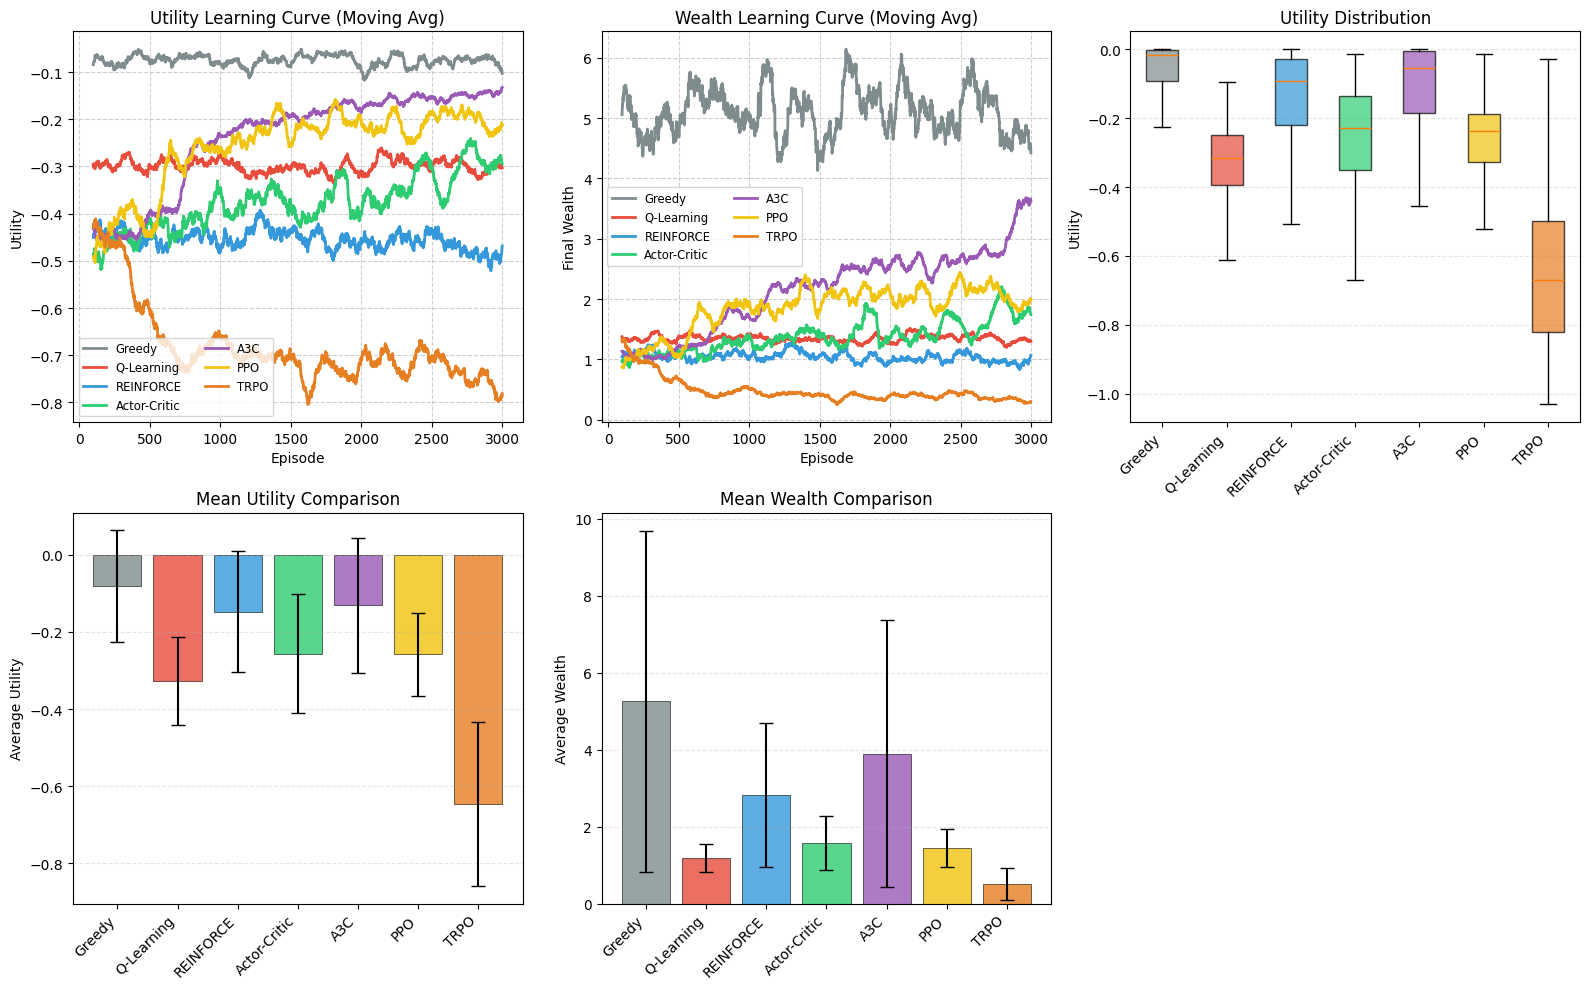


SUMMARY PERFORMANCE METRICS
Algorithm       Mean Utility    Std Utility     Mean Wealth     Std Wealth     
--------------------------------------------------------------------------------
Greedy          -0.0815         0.1450          5.2517          4.4217         
Q-Learning      -0.3276         0.1142          1.1777          0.3585         
REINFORCE       -0.1471         0.1580          2.8295          1.8696         
Actor-Critic    -0.2567         0.1549          1.5729          0.7091         
A3C             -0.1303         0.1751          3.8964          3.4623         
PPO             -0.2584         0.1067          1.4548          0.4944         
TRPO            -0.6464         0.2123          0.5089          0.4245         


<Figure size 640x480 with 0 Axes>


FINAL COMPARISON RESULTS
Algorithm       Mean Utility    Std Utility     Mean Wealth     Std Wealth     
----------------------------------------------------------------------------------------------------
Greedy          -0.0815         0.1450          5.2517          4.4217         
Q-Learning      -0.3276         0.1142          1.1777          0.3585         
REINFORCE       -0.1471         0.1580          2.8295          1.8696         
Actor-Critic    -0.2567         0.1549          1.5729          0.7091         
A3C             -0.1303         0.1751          3.8964          3.4623         
PPO             -0.2584         0.1067          1.4548          0.4944         
TRPO            -0.6464         0.2123          0.5089          0.4245         


In [2]:

T = 8
n_assets = 3
a = [-0.5,0.5, 0.]
s = [0.25,0.25, 0.5]
r = 0.02
p = [0.25,0.25, 0.25, 0.25]
risk_aversion = 1.0
ALLOW_SHORT = False
episodes = 3000
eval_episodes = 500

print(f"{'='*60}")
print(f"Environment Parameters:")
print(f"  Time horizon T = {T}")
print(f"  Number of assets = {n_assets}")
print(f"  Expected returns = {a}")
print(f"  Return variances = {s}")
print(f"  Risk-free rate = {r}")
print(f"  Initial weights = {p}")
print(f"  Risk aversion = {risk_aversion}")
print(f"  Allow short selling = {ALLOW_SHORT}")
print(f"{'='*60}")

actions = generate_actions(n_assets)
print(f"Total actions: {len(actions)}")



results = {}

# 1. Greedy
print(f"\n{'='*60}")
print("Testing Greedy Algorithm (Baseline)...")
env = PortfolioEnv(T, n_assets, a, s, r, p, risk_aversion, ALLOW_SHORT)
agent = GreedyAgent(n_assets, actions)
greedy_wealths = []
greedy_utilities = []
for _ in tqdm(range(episodes), desc="Testing Greedy"):
    w, u = agent.train_episode(env)
    greedy_wealths.append(w)
    greedy_utilities.append(u)

eval_results = evaluate_algorithm("Greedy", agent, env, actions, eval_episodes)
results['Greedy'] = {
    'wealth_history': greedy_wealths,
    'utility_history': greedy_utilities,
    'eval': eval_results
}
print(f"Greedy - Test Wealth: {eval_results['mean_wealth']:.4f} ± {eval_results['std_wealth']:.4f}, "
      f"Test Utility: {eval_results['mean_utility']:.4f} ± {eval_results['std_utility']:.4f}")

# 2. Q-Learning
print(f"\n{'='*60}")
print("Training Q-Learning (Adam adaptive α)...")
env = PortfolioEnv(T, n_assets, a, s, r, p, risk_aversion, ALLOW_SHORT)
agent = AdaptiveQLearningAgent(
    n_assets, 
    initial_alpha=0.1,
    gamma=0.99, 
    epsilon=0.2,
    alpha_strategy='adam',
    min_alpha=0.001,
    max_alpha=0.5
)
wealth_hist, utility_hist = train_algorithm("Q-Learning", agent, env, episodes)
eval_results = evaluate_algorithm("Q-Learning", agent, env, actions, eval_episodes)
results['Q-Learning'] = {
    'wealth_history': wealth_hist,
    'utility_history': utility_hist,
    'eval': eval_results
}
print(f"Q-Learning - Test Wealth: {eval_results['mean_wealth']:.4f} ± {eval_results['std_wealth']:.4f}, "
      f"Test Utility: {eval_results['mean_utility']:.4f} ± {eval_results['std_utility']:.4f}")

# 3. REINFORCE
print(f"\n{'='*60}")
print("Training REINFORCE...")
env = PortfolioEnv(T, n_assets, a, s, r, p, risk_aversion, ALLOW_SHORT)
agent = REINFORCEAgent(n_assets, actions, lr=0.001, gamma=0.99)
wealth_hist, utility_hist = train_algorithm("REINFORCE", agent, env, episodes)
eval_results = evaluate_algorithm("REINFORCE", agent, env, actions, eval_episodes)
results['REINFORCE'] = {
    'wealth_history': wealth_hist,
    'utility_history': utility_hist,
    'eval': eval_results
}
print(f"REINFORCE - Test Wealth: {eval_results['mean_wealth']:.4f} ± {eval_results['std_wealth']:.4f}, "
      f"Test Utility: {eval_results['mean_utility']:.4f} ± {eval_results['std_utility']:.4f}")

# 4. Actor-Critic
print(f"\n{'='*60}")
print("Training Actor-Critic...")
env = PortfolioEnv(T, n_assets, a, s, r, p, risk_aversion, ALLOW_SHORT)
agent = ActorCriticAgent(n_assets, actions, lr=0.001, gamma=0.99)
wealth_hist, utility_hist = train_algorithm("Actor-Critic", agent, env, episodes)
eval_results = evaluate_algorithm("Actor-Critic", agent, env, actions, eval_episodes)
results['Actor-Critic'] = {
    'wealth_history': wealth_hist,
    'utility_history': utility_hist,
    'eval': eval_results
}
print(f"Actor-Critic - Test Wealth: {eval_results['mean_wealth']:.4f} ± {eval_results['std_wealth']:.4f}, "
      f"Test Utility: {eval_results['mean_utility']:.4f} ± {eval_results['std_utility']:.4f}")

# 5. A3C
print(f"\n{'='*60}")
print("Training A3C...")
env = PortfolioEnv(T, n_assets, a, s, r, p, risk_aversion, ALLOW_SHORT)
agent = A3CAgent(n_assets, actions, lr=0.001, gamma=0.99, n_workers=4)
wealth_hist, utility_hist = train_algorithm("A3C", agent, env, episodes)
eval_results = evaluate_algorithm("A3C", agent, env, actions, eval_episodes)
results['A3C'] = {
    'wealth_history': wealth_hist,
    'utility_history': utility_hist,
    'eval': eval_results
}
print(f"A3C - Test Wealth: {eval_results['mean_wealth']:.4f} ± {eval_results['std_wealth']:.4f}, "
      f"Test Utility: {eval_results['mean_utility']:.4f} ± {eval_results['std_utility']:.4f}")

# 6. PPO
print(f"\n{'='*60}")
print("Training PPO...")
env = PortfolioEnv(T, n_assets, a, s, r, p, risk_aversion, ALLOW_SHORT)
agent = PPOAgent(n_assets, actions, lr=0.0003, gamma=0.99)
wealth_hist, utility_hist = train_algorithm("PPO", agent, env, episodes)
eval_results = evaluate_algorithm("PPO", agent, env, actions, eval_episodes)
results['PPO'] = {
    'wealth_history': wealth_hist,
    'utility_history': utility_hist,
    'eval': eval_results
}
print(f"PPO - Test Wealth: {eval_results['mean_wealth']:.4f} ± {eval_results['std_wealth']:.4f}, "
      f"Test Utility: {eval_results['mean_utility']:.4f} ± {eval_results['std_utility']:.4f}")

# 7. TRPO
print(f"\n{'='*60}")
print("Training TRPO...")
env = PortfolioEnv(T, n_assets, a, s, r, p, risk_aversion, ALLOW_SHORT)
agent = TRPOAgent(n_assets, actions, gamma=0.99)
wealth_hist, utility_hist = train_algorithm("TRPO", agent, env, episodes)
eval_results = evaluate_algorithm("TRPO", agent, env, actions, eval_episodes)
results['TRPO'] = {
    'wealth_history': wealth_hist,
    'utility_history': utility_hist,
    'eval': eval_results
}
print(f"TRPO - Test Wealth: {eval_results['mean_wealth']:.4f} ± {eval_results['std_wealth']:.4f}, "
      f"Test Utility: {eval_results['mean_utility']:.4f} ± {eval_results['std_utility']:.4f}")
print(f"\n{'='*60}")
plot_comparison(results, window=100)